In [33]:
from pathlib import Path
from collections import Counter
import hashlib
import json
import os
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import yaml

**Configuration and paths**


In [36]:
SEED = 42
VAL_RATIO = 0.20

CLASS_NAMES = {
    0: "D00_longitudinal_crack",
    1: "D10_transverse_crack",
    2: "D20_alligator_crack",
    3: "D40_pothole",
}

IMAGE_SUFFIXES = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
}

In [ ]:
PROJECT_ROOT = Path.cwd()

DATASET_ROOT = (PROJECT_ROOT / "data" / "processed")

ALL_IMAGES_DIR = (DATASET_ROOT / "all" / "images")
ALL_LABELS_DIR = (DATASET_ROOT / "all" / "labels")

TRAIN_IMAGES_DIR = (DATASET_ROOT / "train" / "images")
TRAIN_LABELS_DIR = (DATASET_ROOT / "train" / "labels")

VAL_IMAGES_DIR = (DATASET_ROOT / "val" / "images")
VAL_LABELS_DIR = (DATASET_ROOT / "val" / "labels")

CONFIGS_DIR = PROJECT_ROOT / "configs"
REPORTS_DIR = PROJECT_ROOT / "reports"

DATA_YAML_PATH = (CONFIGS_DIR / "rdd2022_india.yaml")
SPLIT_REPORT_PATH = (REPORTS_DIR / "rdd2022_split_manifest.json")

print("Unit root   :", PROJECT_ROOT.resolve())
print("Dataset root:", DATASET_ROOT.resolve())

Unit root   : /content
Dataset root: /content/data/processed


**Discover converted image-label pairs**

In [44]:
image_files = sorted(
    path for path in ALL_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_SUFFIXES
)

label_files = sorted(ALL_LABELS_DIR.glob("*.txt"))

images_by_stem = {path.stem: path for path in image_files}
labels_by_stem = {path.stem: path for path in label_files}

images_stems = set(images_by_stem)
label_stems = set(labels_by_stem)

print("Images:", len(image_files))
print("Labels:", len(label_files))

Images: 1934
Labels: 1934


In [45]:
images_without_labels = sorted(images_stems - label_stems)
labels_without_images = sorted(label_stems - images_stems)

if images_without_labels:
    print("Images without labels:",images_without_labels[:10])

if labels_without_images:
    print("Labels without images:", labels_without_images[:10])

**Read class information from labels**

In [46]:
def read_class_ids(label_path):
    text = label_path.read_text(encoding="utf-8").strip()
    class_ids = []
    if not text:
        return []
    
    for line_number, line in enumerate(text.splitlines(), start=1):
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(
                f"{label_path.name}, "
                f"line {line_number}: "
                "expected 5 values"
            )
        
        class_id = int(parts[0])
        if class_id not in CLASS_NAMES:
            raise ValueError(
                f"{label_path.name}: "
                f"invalid class ID {class_id}"
            )
            
        class_ids.append(class_id)

    return class_ids

In [47]:
classes_by_stem = {}

for stem in sorted(images_stems):
    classes_by_stem[stem] = read_class_ids(labels_by_stem[stem])

**Create deterministic 80/20 split**

In [48]:
all_stems = sorted(images_stems)
random_generator = random.Random(SEED)

shuffled_stem = all_stems.copy()
random_generator.shuffle(shuffled_stem)

number_of_validation_images = max(1, round(len(shuffled_stem) * VAL_RATIO))

number_of_validation_images = min(number_of_validation_images, len(shuffled_stem) - 1)

val_stems = sorted(shuffled_stem[:number_of_validation_images])
train_stems = sorted(shuffled_stem[number_of_validation_images:])

train_stem_set = set(train_stems)
val_stem_set = set(val_stems)

print("Total images     :", len(all_stems))
print("Training images  :", len(train_stems))
print("Validation images:", len(val_stems))

Total images     : 1934
Training images  : 1547
Validation images: 387


In [50]:
if train_stem_set & val_stem_set:
    raise RuntimeError(
        "Data leakage: some files exist "
        "in both train and validation."
    )

if (train_stem_set| val_stem_set) != set(all_stems):
    raise RuntimeError("Some images are missing from the split")

actual_val_ratio = len(val_stems) / len(all_stems)
print("Actual validation ratio:", round(actual_val_ratio, 4))

Actual validation ratio: 0.2001


**Calculate split statistics**

In [51]:
def calculate_split_statistics(stems):
    object_counts = Counter()
    image_counts = Counter()
    
    empty_image_count = 0
    total_objects = 0
    
    for stem in stems:
        class_ids = classes_by_stem[stem]
        
        if not class_ids:
            empty_image_count += 1
            continue
        
        object_counts.update(class_ids)
        image_counts.update(set(class_ids))
        
        total_objects += len(class_ids)
        
    return {
        "number_of_images": len(stems),
        "total_objects": total_objects,
        "empty_images": empty_image_count,
        "object_counts": object_counts,
        "image_counts": image_counts,
    }

In [52]:
all_statistics = calculate_split_statistics(all_stems)
train_statistics = calculate_split_statistics(train_stems)
val_statistics = calculate_split_statistics(val_stems)

In [53]:
print("ALL")
print("Images:", all_statistics["number_of_images"],)
print("Objects:", all_statistics["total_objects"],)
print("Empty images:", all_statistics["empty_images"],)

print("\nTRAIN")
print("Images:", train_statistics["number_of_images"],)
print("Objects:", train_statistics["total_objects"],)
print("Empty images:", train_statistics["empty_images"],)

print("\nVALIDATION")
print("Images:", val_statistics["number_of_images"],)
print("Objects:", val_statistics["total_objects"],)
print("Empty images:", val_statistics["empty_images"],)

ALL
Images: 1934
Objects: 4650
Empty images: 0

TRAIN
Images: 1547
Objects: 3745
Empty images: 0

VALIDATION
Images: 387
Objects: 905
Empty images: 0


**Per-class distribution table**

In [54]:
header = (
    f"{'Class':<28}"
    f"{'All obj':>10}"
    f"{'Train obj':>12}"
    f"{'Val obj':>10}"
    f"{'Val %':>10}"
    f"{'Train imgs':>12}"
    f"{'Val imgs':>10}"
)

print(header)
print("-" * len(header))

distribution_warnings = []

for class_id, class_name in CLASS_NAMES.items():
    all_objects = all_statistics["object_counts"][class_id]
    train_objects = train_statistics["object_counts"][class_id]
    val_objects = val_statistics["object_counts"][class_id]
    train_images = train_statistics["image_counts"][class_id]
    val_images = val_statistics["image_counts"][class_id]

    val_percentage = val_objects / all_objects if all_objects > 0 else 0

    print(
        f"{class_name:<28}"
        f"{all_objects:>10}"
        f"{train_objects:>12}"
        f"{val_objects:>10}"
        f"{val_percentage:>9.2%}"
        f"{train_images:>12}"
        f"{val_images:>10}"
    )

    if train_objects == 0:
        distribution_warnings.append(f"{class_name} is missing from train.")

    if val_objects == 0:
        distribution_warnings.append(f"{class_name} is missing from validation.")

    if all_objects > 0 and abs(val_percentage - VAL_RATIO) > 0.05:
        distribution_warnings.append(
            f"{class_name}: validation object ratio is {val_percentage:.2%}, "
            f"expected approximately {VAL_RATIO:.0%}."
        )

Class                          All obj   Train obj   Val obj     Val %  Train imgs  Val imgs
--------------------------------------------------------------------------------------------
D00_longitudinal_crack            2678        2177       501   18.71%        1137       282
D10_transverse_crack              1096         866       230   20.99%         585       153
D20_alligator_crack                641         508       133   20.75%         385       101
D40_pothole                        235         194        41   17.45%         136        28


**Visualize object distribution**

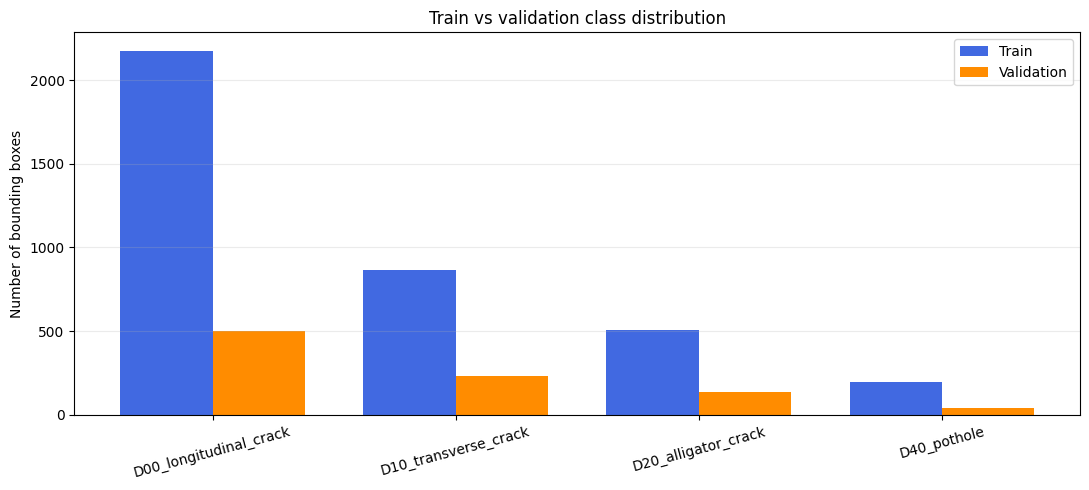

In [56]:
class_ids = list(CLASS_NAMES)
x_positions = np.arange(len(class_ids))
bar_width = 0.38
plt.figure(figsize=(11, 5))

train_object_counts = [train_statistics["object_counts"][class_id] for class_id in class_ids]

val_object_counts = [val_statistics["object_counts"][class_id] for class_id in class_ids]


plt.bar(x_positions - bar_width / 2, train_object_counts, width=bar_width, label="Train", color="royalblue")

plt.bar(x_positions + bar_width / 2, val_object_counts, width=bar_width, label="Validation", color="darkorange")

plt.xticks(x_positions, 
           [CLASS_NAMES[class_id] 
            for class_id in class_ids], 
           rotation=15
)
plt.ylabel("Number of bounding boxes")
plt.title("Train vs validation class distribution")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()